<a href="https://colab.research.google.com/github/jenyabydaev-web/homeworkk/blob/homework/Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

단계 1 완료: 데이터를 성공적으로 불러와서 data/launches.json에 저장했습니다.
불러온 데이터 개수: 10
다운로드 완료: image/rocket_0.jpg
다운로드 완료: image/rocket_1.jpg
다운로드 완료: image/rocket_2.jpg
다운로드 완료: image/rocket_3.jpg
다운로드 완료: image/rocket_4.jpg
다운로드 완료: image/rocket_5.jpg
다운로드 완료: image/rocket_6.jpg
다운로드 완료: image/rocket_7.jpg
다운로드 완료: image/rocket_8.jpg
다운로드 완료: image/rocket_9.jpg
단계 2 완료.


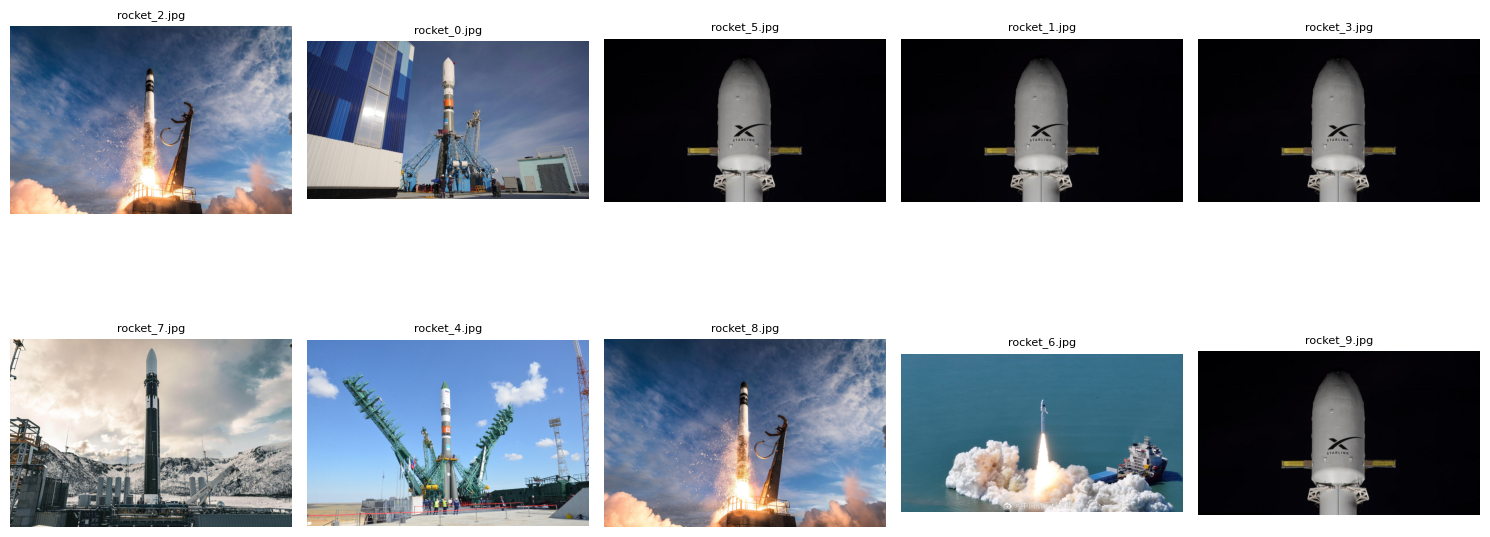

In [1]:
import requests
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def load_data_from_api():
    #(API URL)
    url = "https://ll.thespacedevs.com/2.2.0/launch/upcoming"

    # 'data' 폴더가 없으면 생성
    if not os.path.exists('data'):
        os.makedirs('data')

    try:
        response = requests.get(url)
        response.raise_for_status()  # 네트워크 오류 확인
        data = response.json()

        # 결과를 launches.json 파일로 저장
        with open('data/launches.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        # 구조 확인을 위해 데이터프레임으로 변환
        df = pd.DataFrame(data['results'])
        print("단계 1 완료: 데이터를 성공적으로 불러와서 data/launches.json에 저장했습니다.")
        print(f"불러온 데이터 개수: {len(df)}")
        return df

    except Exception as e:
        print(f"단계 1 오류 발생: {e}")
        return None

df_launches = load_data_from_api()

def get_pictures():
    # 'image' 폴더 생성
    if not os.path.exists('image'):
        os.makedirs('image')

    try:
        # 단계 1에서 저장한 파일 읽기
        with open('data/launches.json', 'r', encoding='utf-8') as f:
            data = json.load(f)

        launches = data.get('results', [])

        for i, launch in enumerate(launches):
            # 최대 50개 이미지로 제한 (선택 과제 조건)
            if i >= 50: break

            img_url = launch.get('image')

            # 예외 처리: URL이 비어있거나 네트워크 오류가 발생하는 경우
            if img_url:
                try:
                    img_data = requests.get(img_url).content
                    filename = f"image/rocket_{i}.jpg"
                    with open(filename, 'wb') as f:
                        f.write(img_data)
                    print(f"다운로드 완료: {filename}")
                except Exception as e:
                    print(f"이미지 {i} 다운로드 실패: {e}")
            else:
                print(f"실행 {i}: 이미지가 존재하지 않습니다.")

        print("단계 2 완료.")

    except FileNotFoundError:
        print("오류: launches.json 파일을 찾을 수 없습니다. 단계 1을 먼저 실행하세요.")

get_pictures()

def visualize_images():
    image_files = [f"image/{img}" for img in os.listdir('image') if img.endswith('.jpg')]

    if not image_files:
        print("표시할 이미지가 없습니다.")
        return

    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(image_files[:15]):  # 예시로 처음 15개만 표시
        plt.subplot(3, 5, i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path), fontsize=8)

    plt.tight_layout()
    plt.show()

visualize_images()